# Stage 0: Setup and Data Loading

In this stage, we download the Air Quality dataset from Kaggle and load it into a Pandas DataFrame.

In [33]:
import kagglehub
import os
import shutil
import pandas as pd

# Download latest version
try:
    path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
    print("Source path from kagglehub:", path)
    
    # Define local dataset directory
    local_dir = "dataset"
    if not os.path.exists(local_dir):
        os.makedirs(local_dir)
        print(f"Created local directory: {local_dir}")
    
    # Copy files to local directory
    for filename in os.listdir(path):
        src_file = os.path.join(path, filename)
        dst_file = os.path.join(local_dir, filename)
        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)
            print(f"Copied {filename} to local {local_dir} folder.")

except Exception as e:
    print(f"Could not download dataset: {e}")
    print("Please ensure you have an internet connection or have downloaded the dataset manually.")

Source path from kagglehub: C:\Users\User\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12
Copied city_day.csv to local dataset folder.
Copied city_hour.csv to local dataset folder.
Copied stations.csv to local dataset folder.
Copied station_day.csv to local dataset folder.
Copied station_hour.csv to local dataset folder.


# Stage 2: Genetic Algorithm Optimization of Fuzzy Inference System

In this stage, we utilize a **Genetic Algorithm (GA)** to automatically tune the parameters of our Sugeno Fuzzy Inference System. 

We optimize:
1. **Membership Function (MF) shapes** for PM2.5 and NO2.
2. **Rule Weights** to prioritize the most relevant fuzzy rules.

The goal is to minimize the **Mean Absolute Error (MAE)** compared to the actual AQI recorded in Delhi.

In [34]:
from helper import fuzzify, evaluate_rule, sugeno_defuzzification, predict_sugeno
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import random
import os
from copy import deepcopy

# Pre-defined Rule Base structure
rule_base = [
    {'if': [('pm2.5', 'High'), ('no2', 'High')], 'then': 500},   # Severe
    {'if': [('pm2.5', 'High'), ('no2', 'Medium')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'High'), ('no2', 'Low')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150}, # Moderate
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'High')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Low'), ('no2', 'Medium')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'Low')], 'then': 50}       # Good
]

def predict_aqi(pm25_val, no2_val, pm25_mf_c, no2_mf_c, rule_base_c, rule_weights_c=None):
    """
    Internal wrapper for inference during GA optimization.
    """
    mf_configs = {
        'pm2.5': pm25_mf_c,
        'no2':   no2_mf_c
    }
    return predict_sugeno({'pm2.5': pm25_val, 'no2': no2_val}, mf_configs, rule_base_c, rule_weights_c)

## 1. GA Configuration and Search Space

In [35]:
# ── Batas pencarian (search bounds) untuk setiap parameter ──
# PM2.5 MF: Low=[a,b], Medium=[a,b,c], High=[a,b]  →  6 parameter
# NO2 MF:  Low=[a,b], Medium=[a,b,c], High=[a,b]   →  6 parameter
# Rule weights: 9 nilai antara [0, 1]

PM25_BOUNDS = [
    (0,   50),   # Low.a
    (20, 120),   # Low.b
    (20, 100),   # Med.a
    (60, 150),   # Med.b (peak)
    (80, 200),   # Med.c
    (80, 300),   # High.a
    (120, 400),  # High.b
]

NO2_BOUNDS = [
    (0,   80),   # Low.a
    (20, 150),   # Low.b
    (20, 120),   # Med.a
    (60, 200),   # Med.b (peak)
    (100, 300),  # Med.c
    (100, 350),  # High.a
    (150, 400),  # High.b
]

RULE_WEIGHT_BOUNDS = [(0.0, 1.0)] * 9  # 9 rules

ALL_BOUNDS = PM25_BOUNDS + NO2_BOUNDS + RULE_WEIGHT_BOUNDS
CHROM_LEN = len(ALL_BOUNDS)
print(f"Panjang kromosom: {CHROM_LEN} gen")
print(f"  • PM2.5 MF params : {len(PM25_BOUNDS)}")
print(f"  • NO2 MF params   : {len(NO2_BOUNDS)}")
print(f"  • Rule weights    : {len(RULE_WEIGHT_BOUNDS)}")

# Template rule base (bagian 'then' tetap dari Stage 1)

def decode_chromosome(chrom):
    """Ubah kromosom (list float) menjadi MF dict + rule_weights."""
    p = chrom  # alias

    # -- PM2.5 MF --
    pm25_mf_c = {
        'Low':    ('left_shoulder',  [p[0], p[1]]),
        'Medium': ('triangular',     [p[2], p[3], p[4]]),
        'High':   ('right_shoulder', [p[5], p[6]]),
    }

    # -- NO2 MF --
    no2_mf_c = {
        'Low':    ('left_shoulder',  [p[7],  p[8]]),
        'Medium': ('triangular',     [p[9],  p[10], p[11]]),
        'High':   ('right_shoulder', [p[12], p[13]]),
    }

    # -- Rule weights --
    rule_weights = list(p[14:23])

    return pm25_mf_c, no2_mf_c, rule_weights

def random_chromosome():
    """Buat kromosom acak dalam batas yang valid."""
    chrom = [random.uniform(lo, hi) for lo, hi in ALL_BOUNDS]
    return enforce_order(chrom)

def enforce_order(chrom):
    """Pastikan urutan parameter MF monoton (a<=b<=c) agar shape MF valid."""
    c = list(chrom)
    # PM2.5: Low.a <= Low.b
    c[0], c[1] = sorted([c[0], c[1]])
    # PM2.5 Medium: a <= peak <= c
    c[2], c[3], c[4] = sorted([c[2], c[3], c[4]])
    # PM2.5 High: a <= b
    c[5], c[6] = sorted([c[5], c[6]])
    # NO2: sama
    c[7],  c[8]  = sorted([c[7],  c[8]])
    c[9],  c[10], c[11] = sorted([c[9], c[10], c[11]])
    c[12], c[13] = sorted([c[12], c[13]])
    return c

print("✅ Encoding/decoding kromosom siap.")


Panjang kromosom: 23 gen
  • PM2.5 MF params : 7
  • NO2 MF params   : 7
  • Rule weights    : 9
✅ Encoding/decoding kromosom siap.


In [36]:
def compute_mae(chrom, data_pm25, data_no2, data_aqi):
    """Hitung MAE untuk satu kromosom pada dataset."""
    pm25_mf_c, no2_mf_c, rule_weights = decode_chromosome(chrom)
    preds = np.array([
        predict_aqi(p, n, pm25_mf_c, no2_mf_c, rule_base, rule_weights)
        for p, n in zip(data_pm25, data_no2)
    ])
    return np.mean(np.abs(preds - data_aqi))

def fitness(chrom, data_pm25, data_no2, data_aqi):
    """Fitness = 1/(1+MAE) agar lebih besar = lebih baik."""
    return 1.0 / (1.0 + compute_mae(chrom, data_pm25, data_no2, data_aqi))

# ── Operator Genetik ──

def tournament_selection(population, fitnesses, k=3):
    """Pilih 1 individu terbaik dari k kandidat acak."""
    candidates = random.sample(range(len(population)), k)
    best = max(candidates, key=lambda i: fitnesses[i])
    return population[best][:]

def blend_crossover(parent1, parent2, alpha=0.5):
    """BLX-α crossover: anak berada dalam rentang [min-α*range, max+α*range]."""
    child = []
    for g1, g2, (lo, hi) in zip(parent1, parent2, ALL_BOUNDS):
        lo_g, hi_g = min(g1, g2), max(g1, g2)
        r = hi_g - lo_g
        new_lo = max(lo, lo_g - alpha * r)
        new_hi = min(hi, hi_g + alpha * r)
        child.append(random.uniform(new_lo, new_hi) if new_lo < new_hi else lo_g)
    return enforce_order(child)

def gaussian_mutation(chrom, mutation_rate=0.15, sigma_frac=0.1):
    """Mutasi Gaussian: tambah noise proporsional terhadap range batas."""
    mutated = list(chrom)
    for i, (lo, hi) in enumerate(ALL_BOUNDS):
        if random.random() < mutation_rate:
            sigma = sigma_frac * (hi - lo)
            mutated[i] = np.clip(mutated[i] + random.gauss(0, sigma), lo, hi)
    return enforce_order(mutated)

# ── Main GA Loop ──

def run_ga(data_pm25, data_no2, data_aqi,
           pop_size=60, n_generations=80,
           crossover_rate=0.8, mutation_rate=0.15,
           elitism=3, seed=42):
    """
    Jalankan Genetic Algorithm.
    
    Returns
    -------
    best_chrom      : kromosom terbaik
    best_mae_hist   : list MAE terbaik per generasi
    avg_mae_hist    : list MAE rata-rata per generasi
    """
    random.seed(seed)
    np.random.seed(seed)

    # Inisialisasi populasi
    population = [random_chromosome() for _ in range(pop_size)]
    
    best_mae_hist = []
    avg_mae_hist  = []
    best_chrom    = None
    best_mae      = float('inf')

    print(f"{'Gen':>5} | {'Best MAE':>10} | {'Avg MAE':>10} | {'Improvement':>12}")
    print("-" * 46)

    for gen in range(n_generations):
        # Evaluasi fitness
        fitnesses = [fitness(c, data_pm25, data_no2, data_aqi) for c in population]
        maes      = [compute_mae(c, data_pm25, data_no2, data_aqi) for c in population]

        gen_best_mae = min(maes)
        gen_avg_mae  = np.mean(maes)
        best_mae_hist.append(gen_best_mae)
        avg_mae_hist.append(gen_avg_mae)

        # Update global best
        if gen_best_mae < best_mae:
            best_mae   = gen_best_mae
            best_chrom = population[np.argmin(maes)][:]
            improved   = "⬆ improved"
        else:
            improved = ""

        if gen % 10 == 0 or improved:
            print(f"{gen+1:>5} | {gen_best_mae:>10.2f} | {gen_avg_mae:>10.2f} | {improved}")

        # Elitism: pertahankan individu terbaik
        sorted_idx  = sorted(range(pop_size), key=lambda i: maes[i])
        new_pop     = [population[i][:] for i in sorted_idx[:elitism]]

        # Buat generasi baru
        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            if random.random() < crossover_rate:
                p2    = tournament_selection(population, fitnesses)
                child = blend_crossover(p1, p2)
            else:
                child = p1[:]
            child = gaussian_mutation(child, mutation_rate)
            new_pop.append(child)

        population = new_pop

    print(f"\n✅ GA selesai. Best MAE = {best_mae:.4f}")
    return best_chrom, best_mae_hist, avg_mae_hist

print("✅ GA engine siap.")


✅ GA engine siap.


In [37]:
# ── Restore Manual FIS Baseline (Stage 1) for Performance Comparison ──
PM25_MF_CONFIG = {
    'Low':    ('left_shoulder',  [30, 60]),
    'Medium': ('triangular',     [45, 90, 135]),
    'High':   ('right_shoulder', [110, 200])
}

NO2_MF_CONFIG = {
    'Low':    ('left_shoulder',  [40, 80]),
    'Medium': ('triangular',     [60, 130, 200]),
    'High':   ('right_shoulder', [160, 300])
}

def predict_aqi_manual(pm25_val, no2_val):
    """Manual inference engine from Stage 1."""
    mf_configs = {
        'pm2.5': PM25_MF_CONFIG,
        'no2':   NO2_MF_CONFIG
    }
    return predict_sugeno({'pm2.5': pm25_val, 'no2': no2_val}, mf_configs, rule_base)

print("✅ Manual FIS baseline setup complete.")

✅ Manual FIS baseline setup complete.


In [38]:
import os

csv_path = os.path.join("dataset", "city_day.csv")
raw_df   = pd.read_csv(csv_path)
delhi_df = raw_df[raw_df['City'] == 'Delhi'][['Date','PM2.5','NO2','AQI']].dropna()
delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])

data_pm25 = delhi_df['PM2.5'].values
data_no2  = delhi_df['NO2'].values
data_aqi  = delhi_df['AQI'].values

print(f"Data Delhi siap: {len(delhi_df)} baris")


# ── Jalankan GA ──
print("\n🔄 Menjalankan Genetic Algorithm...")
best_chrom, best_mae_hist, avg_mae_hist = run_ga(
    data_pm25, data_no2, data_aqi,
    pop_size     = 60,
    n_generations= 80,
    mutation_rate= 0.15,
    seed         = 42
)

mae_ga = best_mae_hist[-1]
print(f"\n📌 MAE Setelah GA Tuning (Tahap 3):  {mae_ga:.2f}")

# ── Hitung MAE baseline (Manual FIS) ──
preds_manual = np.array([
    predict_aqi_manual(p, n) for p, n in zip(data_pm25, data_no2)
])
mae_baseline = np.mean(np.abs(preds_manual - data_aqi))
print(f"📌 MAE Baseline (Manual FIS): {mae_baseline:.2f}")


Data Delhi siap: 1998 baris

🔄 Menjalankan Genetic Algorithm...
  Gen |   Best MAE |    Avg MAE |  Improvement
----------------------------------------------
    1 |      92.38 |     164.83 | ⬆ improved
    2 |      76.66 |     137.21 | ⬆ improved
    3 |      68.85 |     112.12 | ⬆ improved
    4 |      66.89 |      96.77 | ⬆ improved
    6 |      64.58 |      76.68 | ⬆ improved
    7 |      62.43 |      70.60 | ⬆ improved
    8 |      59.46 |      67.57 | ⬆ improved
    9 |      56.97 |      64.43 | ⬆ improved
   11 |      53.43 |      60.99 | ⬆ improved
   12 |      51.73 |      59.50 | ⬆ improved
   14 |      49.86 |      56.31 | ⬆ improved
   15 |      48.93 |      53.98 | ⬆ improved
   16 |      48.60 |      53.37 | ⬆ improved
   18 |      47.92 |      51.29 | ⬆ improved
   19 |      47.69 |      50.90 | ⬆ improved
   21 |      47.52 |      50.90 | ⬆ improved
   23 |      47.09 |      49.49 | ⬆ improved
   25 |      47.01 |      48.33 | ⬆ improved
   26 |      46.94 |      49.21 

In [39]:
# ── Tampilkan parameter optimal hasil GA ──
pm25_mf_ga, no2_mf_ga, rw_ga = decode_chromosome(best_chrom)

# ── Hitung prediksi model GA untuk seluruh data ──
preds_ga = np.array([
    predict_aqi(p, n, pm25_mf_ga, no2_mf_ga, rule_base, rw_ga)
    for p, n in zip(data_pm25, data_no2)
])

print("=" * 55)
print("  PARAMETER OPTIMAL HASIL GENETIC ALGORITHM")
print("=" * 55)

print("\n📐 PM2.5 Membership Functions:")
for label, (mf_type, params) in pm25_mf_ga.items():
    formatted = [f"{v:.1f}" for v in params]
    print(f"   {label:8s} ({mf_type:>14s}): {formatted}")

print("\n📐 NO2 Membership Functions:")
for label, (mf_type, params) in no2_mf_ga.items():
    formatted = [f"{v:.1f}" for v in params]
    print(f"   {label:8s} ({mf_type:>14s}): {formatted}")

print("\n⚖️  Rule Weights (9 rules):")
for i, (rule, w) in enumerate(zip(rule_base, rw_ga)):
    conds = " AND ".join([f"{var.upper()}={lbl}" for var, lbl in rule['if']])
    status = "✅" if w >= 0.3 else "❌ (lemah)"
    print(f"   Rule {i+1}: {conds:40s} → w={w:.3f} {status}")

print("\n📊 Perbandingan Manual vs GA:")
print(f"   MAE Manual FIS : {mae_baseline:.2f}")
print(f"   MAE GA Tuned   : {mae_ga:.2f}")
print(f"   Selisih        : {mae_baseline - mae_ga:.2f} ({(mae_baseline-mae_ga)/mae_baseline*100:.1f}%)")


  PARAMETER OPTIMAL HASIL GENETIC ALGORITHM

📐 PM2.5 Membership Functions:
   Low      ( left_shoulder): ['21.1', '51.8']
   Medium   (    triangular): ['36.6', '61.5', '153.0']
   High     (right_shoulder): ['80.0', '120.1']

📐 NO2 Membership Functions:
   Low      ( left_shoulder): ['0.0', '21.8']
   Medium   (    triangular): ['20.9', '93.5', '111.9']
   High     (right_shoulder): ['100.0', '297.5']

⚖️  Rule Weights (9 rules):
   Rule 1: PM2.5=High AND NO2=High                  → w=0.718 ✅
   Rule 2: PM2.5=High AND NO2=Medium                → w=1.000 ✅
   Rule 3: PM2.5=High AND NO2=Low                   → w=1.000 ✅
   Rule 4: PM2.5=Medium AND NO2=High                → w=0.486 ✅
   Rule 5: PM2.5=Medium AND NO2=Medium              → w=0.654 ✅
   Rule 6: PM2.5=Medium AND NO2=Low                 → w=0.090 ❌ (lemah)
   Rule 7: PM2.5=Low AND NO2=High                   → w=0.557 ✅
   Rule 8: PM2.5=Low AND NO2=Medium                 → w=0.675 ✅
   Rule 9: PM2.5=Low AND NO2=Low             

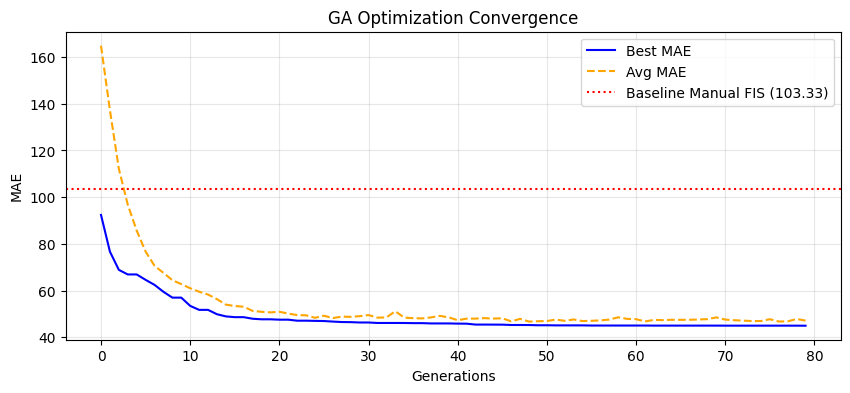

In [40]:
# Plot Convergence Curve (Genetic Algorithm)
plt.figure(figsize=(10, 4))
plt.plot(best_mae_hist, label='Best MAE', color='blue')
plt.plot(avg_mae_hist,  label='Avg MAE',  color='orange', linestyle='--')
plt.axhline(mae_baseline, color='red', linestyle=':', label=f'Baseline Manual FIS ({mae_baseline:.2f})')
plt.title('GA Optimization Convergence')
plt.xlabel('Generations')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

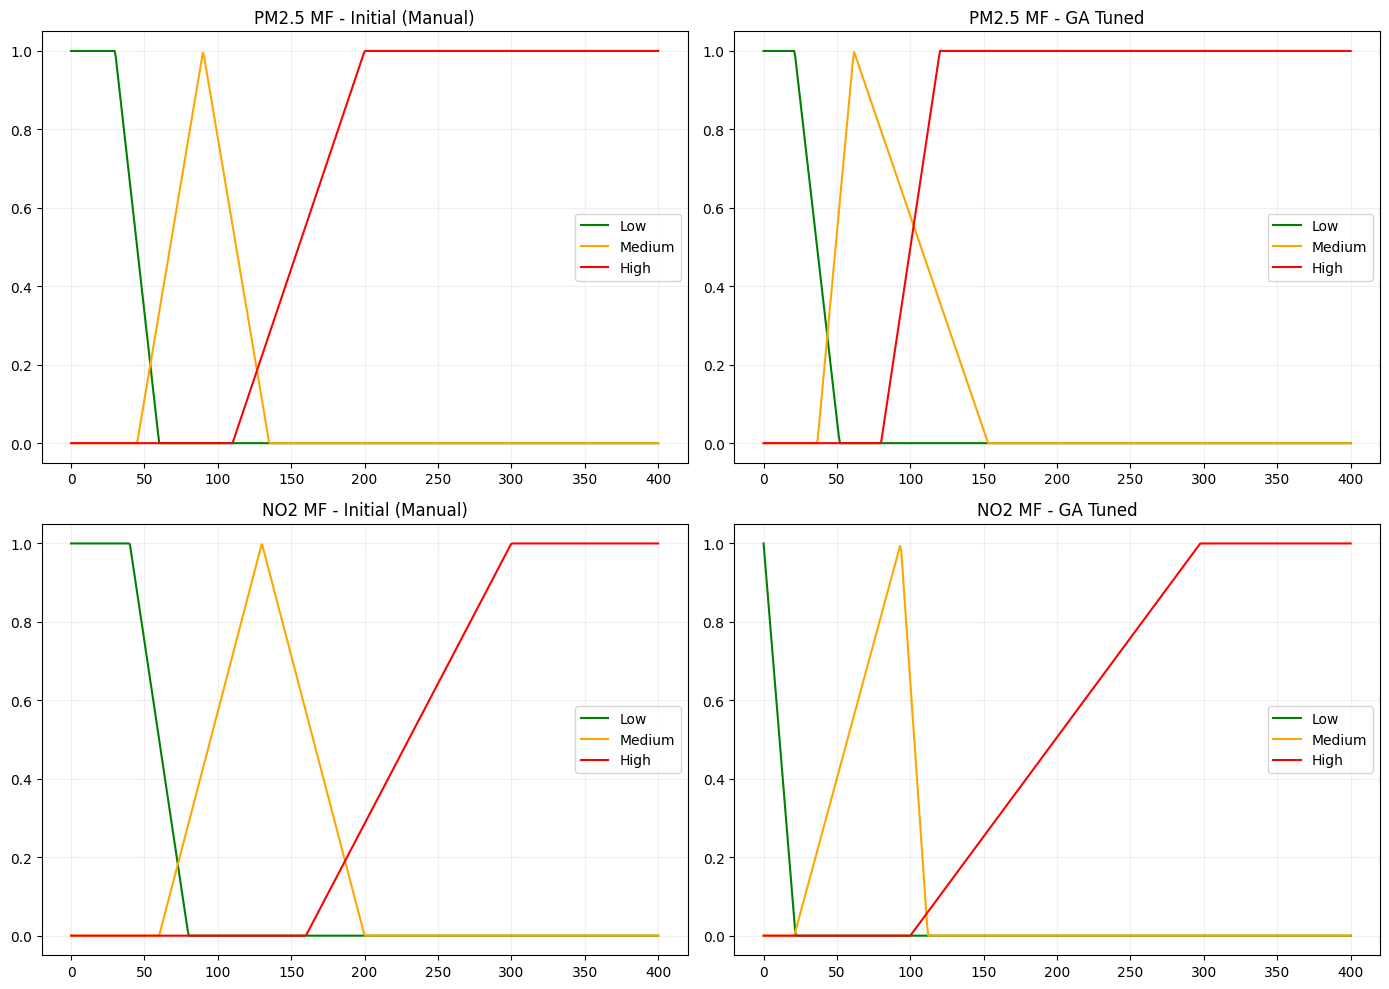

In [41]:
# ── Plot Membership Functions: Initial (Manual) vs. GA Tuned ──
x_pm25 = np.linspace(0, 400, 500)
x_no2  = np.linspace(0, 400, 500)
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PM2.5 Initial (Manual)
for label, (mf_type, params) in PM25_MF_CONFIG.items():
    y = [fuzzify(v, {'x': (mf_type, params)})['x'] for v in x_pm25]
    axes[0, 0].plot(x_pm25, y, color=colors[label], label=label)
axes[0, 0].set_title("PM2.5 MF - Initial (Manual)"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.2)

# PM2.5 GA Tuned
for label, (mf_type, params) in pm25_mf_ga.items():
    y = [fuzzify(v, {'x': (mf_type, params)})['x'] for v in x_pm25]
    axes[0, 1].plot(x_pm25, y, color=colors[label], label=label)
axes[0, 1].set_title("PM2.5 MF - GA Tuned"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.2)

# NO2 Initial (Manual)
for label, (mf_type, params) in NO2_MF_CONFIG.items():
    y = [fuzzify(v, {'x': (mf_type, params)})['x'] for v in x_no2]
    axes[1, 0].plot(x_no2, y, color=colors[label], label=label)
axes[1, 0].set_title("NO2 MF - Initial (Manual)"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.2)

# NO2 GA Tuned
for label, (mf_type, params) in no2_mf_ga.items():
    y = [fuzzify(v, {'x': (mf_type, params)})['x'] for v in x_no2]
    axes[1, 1].plot(x_no2, y, color=colors[label], label=label)
axes[1, 1].set_title("NO2 MF - GA Tuned"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

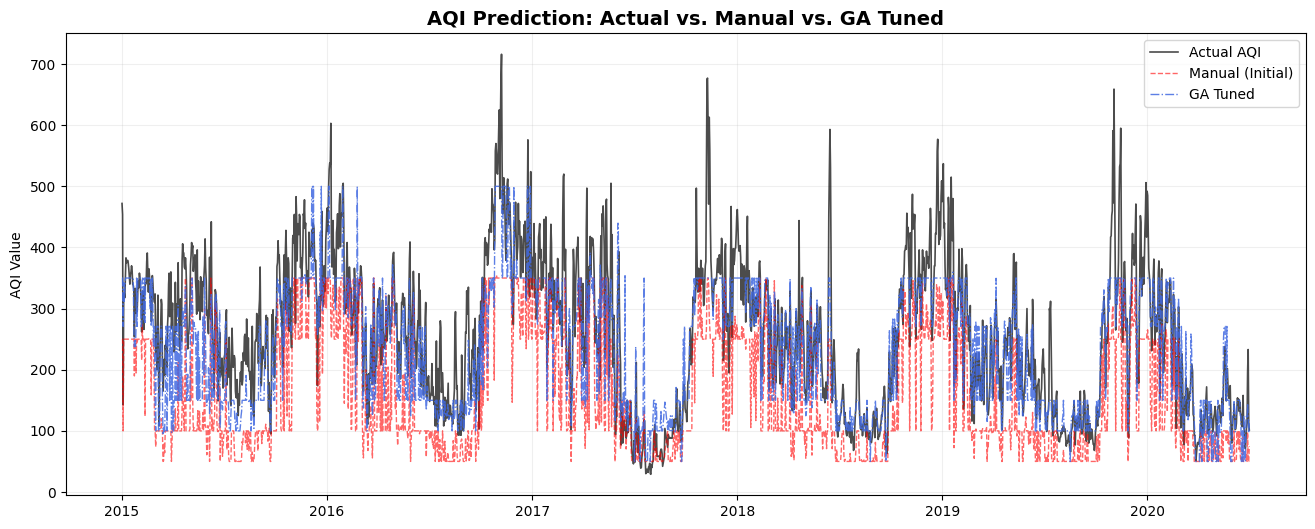

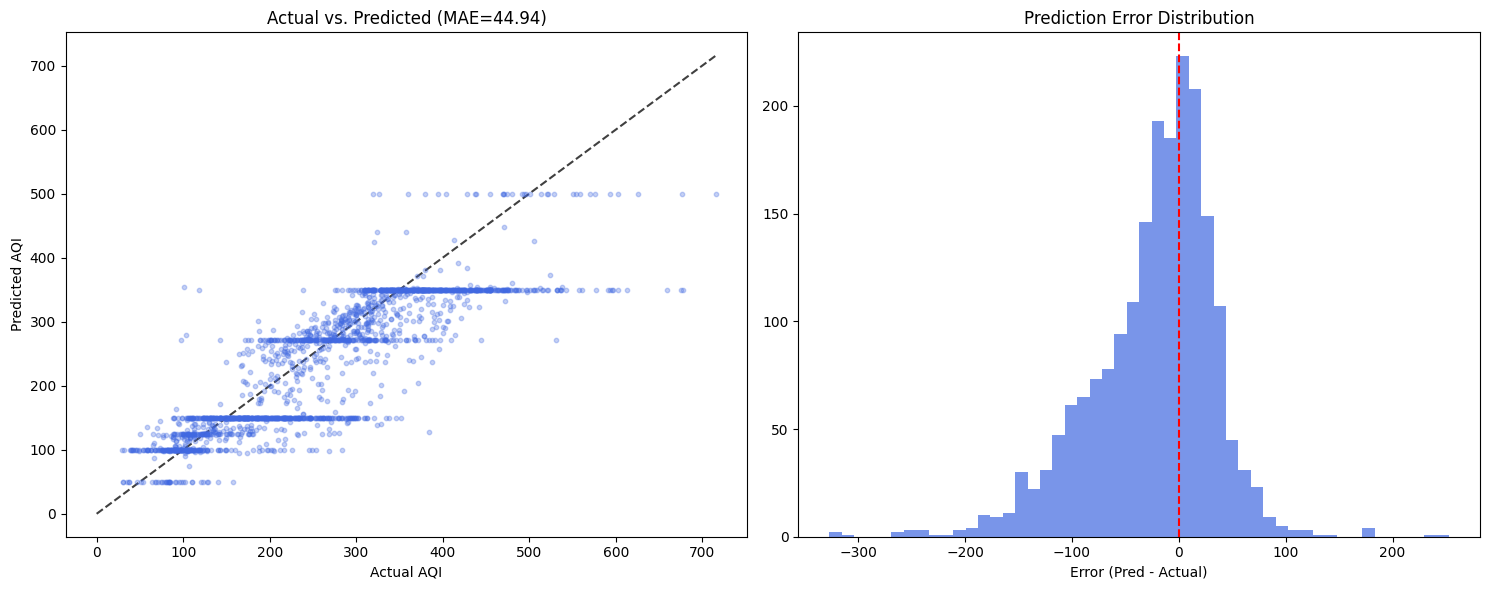

In [42]:
# ── Performance Comparison: Time Series Analysis ──
plt.figure(figsize=(16, 6))
plt.plot(delhi_df['Date'], data_aqi,      label='Actual AQI',      color='black',     linewidth=1.2, alpha=0.7)
plt.plot(delhi_df['Date'], preds_manual,  label='Manual (Initial)', color='red',       linewidth=1,   linestyle='--', alpha=0.6)
plt.plot(delhi_df['Date'], preds_ga,      label='GA Tuned',        color='royalblue', linewidth=1,   linestyle='-.', alpha=0.85)
plt.title('AQI Prediction: Actual vs. Manual vs. GA Tuned', fontsize=14, fontweight='bold')
plt.ylabel('AQI Value'); plt.legend(); plt.grid(alpha=0.2)
plt.show()

# ── Scatter Plot and Error Distribution ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
ax1.scatter(data_aqi, preds_ga, alpha=0.3, s=10, color='royalblue')
lims = [0, max(data_aqi.max(), preds_ga.max())]
ax1.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax1.set_xlabel('Actual AQI'); ax1.set_ylabel('Predicted AQI')
ax1.set_title(f'Actual vs. Predicted (MAE={mae_ga:.2f})')

# Error distribution
errors = preds_ga - data_aqi
ax2.hist(errors, bins=50, color='royalblue', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('Error (Pred - Actual)'); ax2.set_title('Prediction Error Distribution')

plt.tight_layout()
plt.show()

In [43]:
print("=" * 60)
print("  RINGKASAN HASIL — PERBANDINGAN TAHAP 1 vs TAHAP 3")
print("=" * 60)

r2_manual = 1 - np.sum((data_aqi - preds_manual)**2) / np.sum((data_aqi - data_aqi.mean())**2)
r2_ga     = 1 - np.sum((data_aqi - preds_ga)**2)     / np.sum((data_aqi - data_aqi.mean())**2)
rmse_m    = np.sqrt(np.mean((data_aqi - preds_manual)**2))
rmse_ga   = np.sqrt(np.mean((data_aqi - preds_ga)**2))

print(f"{'Metrik':<25} {'Manual FIS':>12} {'GA Tuned':>12} {'Δ':>10}")
print("-" * 62)
print(f"{'MAE':<25} {mae_baseline:>12.2f} {mae_ga:>12.2f} {mae_baseline-mae_ga:>+10.2f}")
print(f"{'RMSE':<25} {rmse_m:>12.2f} {rmse_ga:>12.2f} {rmse_m-rmse_ga:>+10.2f}")
print(f"{'R² Score':<25} {r2_manual:>12.4f} {r2_ga:>12.4f} {r2_ga-r2_manual:>+10.4f}")
print("=" * 62)
print(f"\n🏆 Peningkatan MAE  : {(mae_baseline - mae_ga)/mae_baseline*100:.1f}%")
print(f"🏆 Peningkatan RMSE : {(rmse_m - rmse_ga)/rmse_m*100:.1f}%")
print(f"🏆 Peningkatan R²   : {(r2_ga - r2_manual)/abs(r2_manual)*100:.1f}%")
print("\n📝 Catatan:")
print("   • GA mengoptimasi 7+7=14 parameter MF dan 9 rule weights")
print("   • Populasi: 60 individu | Generasi: 80 | Elitism: 3")
print("   • Operator: BLX-α crossover + Gaussian mutation")


  RINGKASAN HASIL — PERBANDINGAN TAHAP 1 vs TAHAP 3
Metrik                      Manual FIS     GA Tuned          Δ
--------------------------------------------------------------
MAE                             103.33        44.94     +58.40
RMSE                            120.61        63.05     +57.56
R² Score                       -0.0196       0.7213    +0.7410

🏆 Peningkatan MAE  : 56.5%
🏆 Peningkatan RMSE : 47.7%
🏆 Peningkatan R²   : 3773.9%

📝 Catatan:
   • GA mengoptimasi 7+7=14 parameter MF dan 9 rule weights
   • Populasi: 60 individu | Generasi: 80 | Elitism: 3
   • Operator: BLX-α crossover + Gaussian mutation


In [44]:
import json
import os
import numpy as np

# Convert any numpy types to standard python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64, np.floating)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64, np.integer)):
        return int(obj)
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

results = {
    "best_chrom": convert_to_serializable(best_chrom),
    "pm25_mf_ga": convert_to_serializable(pm25_mf_ga),
    "no2_mf_ga": convert_to_serializable(no2_mf_ga),
    "rw_ga": convert_to_serializable(rw_ga)
}

os.makedirs("results", exist_ok=True)
with open(os.path.join("results", "ga_results.json"), "w") as f:
    json.dump(results, f, indent=4)

print("✅ GA results exported to results/ga_results.json")

✅ GA results exported to results/ga_results.json
